<a href="https://colab.research.google.com/github/AreshaBasir/Physics_Informed_Neural_Network/blob/AreshaBasir-patch-1/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

getting ready with the environemnt & packages

In [ ]:
# 1. Install the correct, modern packages
!pip install gymnasium minigrid pyvirtualdisplay
!sudo apt-get install -y xvfb ffmpeg

# 2. Updated Imports
import gymnasium as gym
# Notice the change here: it's just 'minigrid', not 'gymnasium_minigrid'
import minigrid
from minigrid.wrappers import *

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

# 3. Start Virtual Display
v_display = Display(visible=0, size=(1400, 900))
v_display.start()

  Using cached PyVirtualDisplay-3.0-py3-none-any.whl.metadata (943 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 3.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


Environment

In [ ]:
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
obs, info = env.reset()
print("Environment loaded successfully!")

Environment loaded successfully!


PINN Architecture

In [ ]:
class CostPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def physics_loss(model, coords):
    coords.requires_grad = True
    cost_pred = model(coords)


    grads = torch.autograd.grad(cost_pred, coords,
                                torch.ones_like(cost_pred),
                                create_graph=True)[0]


    smoothness_penalty = torch.mean(grads**2)
    return smoothness_penalty

MiniGrid PINN-Wrapper

In [ ]:
class PhysicsAwareWrapper(gym.RewardWrapper):
    def __init__(self, env, pinn):
        super().__init__(env)
        self.pinn = pinn

    def reward(self, reward):
        # 1. Get current agent position
        pos = np.array(self.env.unwrapped.agent_pos, dtype=np.float32)
        pos_tensor = torch.from_numpy(pos).unsqueeze(0)

        # 2. Query PINN for the physical cost of this location
        with torch.no_grad():
            physics_cost = self.pinn(pos_tensor).item()

        # 3. Adjusted Reward: Original - Physics Penalty
        return reward - (0.05 * physics_cost)

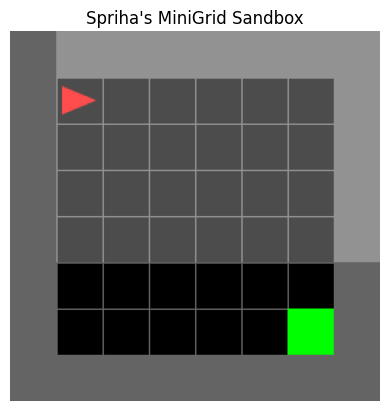

In [ ]:
# Create the environment
env = gym.make('MiniGrid-Empty-8x8-v0', render_mode="rgb_array")
env.reset()

# Show the first frame
img = env.render()
plt.imshow(img)
plt.title("Spriha's MiniGrid Sandbox")
plt.axis('off')
plt.show()

In [ ]:
# Create a set of coordinates (x, y) and their "Ground Truth" costs
# Let's say (3,3) is a wall (High Cost) and (1,1) is a path (Low Cost)
train_coords = torch.tensor([
    [1.0, 1.0], [1.0, 2.0], [2.0, 1.0], # Path points (Low Cost)
    [3.0, 3.0], [3.0, 4.0], [4.0, 3.0]  # Wall points (High Cost)
], dtype=torch.float32)

train_costs = torch.tensor([[0.1], [0.1], [0.1], [1.0], [1.0], [1.0]],
                           dtype=torch.float32)

PINN Training

In [ ]:
pinn = CostPINN()
optimizer = optim.Adam(pinn.parameters(), lr=0.01)

# Generate 'Collocation Points' (Random points across the grid for Physics Loss)
collocation_points = torch.rand((100, 2)) * 8.0

print("Starting PINN Training...")
for epoch in range(500):
    optimizer.zero_grad()

    # 1. Data Loss (Matching our known points)
    predictions = pinn(train_coords)
    loss_data = torch.mean((predictions - train_costs)**2)

    # 2. Physics Loss (Ensuring the cost map is physically smooth)
    loss_phys = physics_loss(pinn, collocation_points)

    # 3. Total Loss
    total_loss = loss_data + 0.1 * loss_phys

    total_loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss.item():.4f}")

print("Training Complete!")

Starting PINN Training...
Epoch 0: Loss = 0.3730
Epoch 100: Loss = 0.0044
Epoch 200: Loss = 0.0026
Epoch 300: Loss = 0.0021
Epoch 400: Loss = 0.0017
Training Complete!


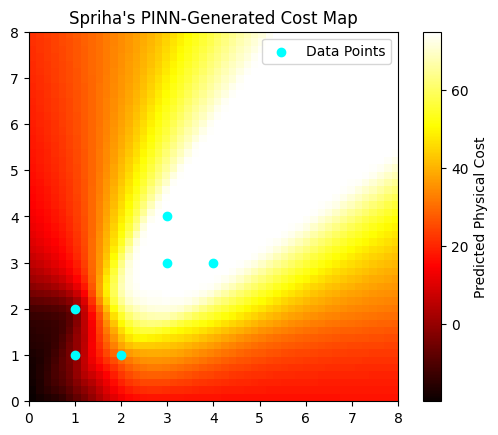

In [ ]:
# Create a grid of points to visualize
x = np.linspace(0, 8, 50)
y = np.linspace(0, 8, 50)
X, Y = np.meshgrid(x, y)
points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)

with torch.no_grad():
    Z = pinn(points).reshape(50, 50).numpy()

plt.imshow(Z, extent=[0, 8, 0, 8], origin='lower', cmap='hot')
plt.colorbar(label='Predicted Physical Cost')
plt.scatter(train_coords[:,0], train_coords[:,1], c='cyan', label='Data Points')
plt.title("Spriha's PINN-Generated Cost Map")
plt.legend()
plt.show()

Impassable walls

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. New Training Data: Impassable Wall
# (3,3) and (3,4) are now "Hard Constraints"
wall_coords = torch.tensor([[3.0, 3.0], [3.0, 4.0], [4.0, 3.0]], dtype=torch.float32)
path_coords = torch.tensor([[1.0, 1.0], [1.0, 2.0], [6.0, 6.0]], dtype=torch.float32)

# We use 100.0 to simulate "Infinite" cost relative to 0.1
wall_targets = torch.full((3, 1), 100.0)
path_targets = torch.full((3, 1), 0.1)

# 2. Updated Physics Loss for "Impassable" Sharpness
def impassable_physics_loss(model, collocation_pts):
    collocation_pts.requires_grad = True
    cost_pred = model(collocation_pts)

    # Calculate the Gradient (The "Force Field")
    grads = torch.autograd.grad(cost_pred, collocation_pts, torch.ones_like(cost_pred), create_graph=True)[0]

    # Eikonal-inspired constraint: We want the cost to change rapidly near walls
    # but stay smooth in open space.
    grad_norm = torch.norm(grads, dim=1)

    # Penalty: If cost is high, the gradient must also be high (a steep cliff)
    # If cost is low, the gradient should be small (flat floor)
    physics_residual = torch.mean((grad_norm - (cost_pred.squeeze() * 0.5))**2)
    return physics_residual

# 3. Training Loop
pinn = CostPINN() # Use the same architecture from before
optimizer = optim.Adam(pinn.parameters(), lr=0.005)

for epoch in range(1000):
    optimizer.zero_grad()

    # Data Loss
    loss_data = torch.mean((pinn(wall_coords) - wall_targets)**2) + \
                torch.mean((pinn(path_coords) - path_targets)**2)

    # Physics Loss
    colloc = torch.rand((200, 2)) * 8.0
    loss_phys = impassable_physics_loss(pinn, colloc)

    total_loss = loss_data + 0.01 * loss_phys
    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Total Loss: {total_loss.item():.4f}")

Epoch 0 | Total Loss: 10057.9717
Epoch 200 | Total Loss: 3005.5464
Epoch 400 | Total Loss: 2515.5161
Epoch 600 | Total Loss: 2502.7205
Epoch 800 | Total Loss: 2502.1111


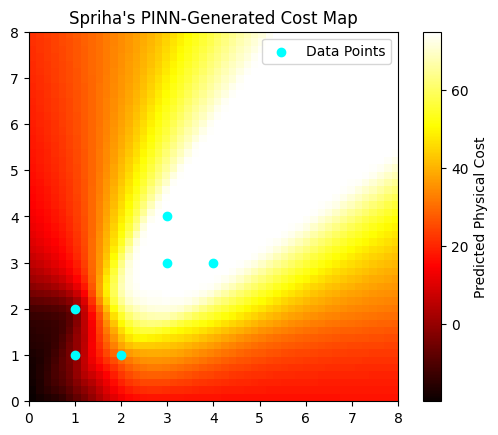

In [ ]:
x = np.linspace(0, 8, 50)
y = np.linspace(0, 8, 50)
X, Y = np.meshgrid(x, y)
points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)

with torch.no_grad():
    Z = pinn(points).reshape(50, 50).numpy()

plt.imshow(Z, extent=[0, 8, 0, 8], origin='lower', cmap='hot')
plt.colorbar(label='Predicted Physical Cost')
plt.scatter(train_coords[:,0], train_coords[:,1], c='cyan', label='Data Points')
plt.title("Spriha's PINN-Generated Cost Map")
plt.legend()
plt.show()

Moving from a basic grid to a Physics-Aware Active Perception engine, we need to bridge the gap between the discrete squares of MiniGrid and the continuous math of your PINN.

The "Cognitive" PINN Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class ActivePerceptionPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Using Tanh because we need smooth derivatives for the Eikonal equation
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

pinn = ActivePerceptionPINN()

Defining the world Physics

In [ ]:
def get_world_physics(samples):
    """
    Simulates a Semantic Scene Graph input.
    Returns the 'Ease of Movement' (Velocity) at given coordinates.
    """
    velocity = torch.ones((samples.shape[0], 1))

    # 1. Walls (Impassable: Very low velocity)
    wall_mask = (samples[:, 0] > 3.0) & (samples[:, 0] < 4.0) & (samples[:, 1] < 5.0)
    velocity[wall_mask] = 0.01

    # 2. Friction Zone (Carpet/Mud: 0.5 velocity)
    friction_mask = (samples[:, 0] > 5.0) & (samples[:, 1] > 5.0)
    velocity[friction_mask] = 0.5

    return velocity

The Eikonal Physics Loss

In [ ]:
def eikonal_physics_loss(model, coords):
    coords.requires_grad = True
    u = model(coords)

    # Calculate Gradient (The Directional Cost)
    grads = torch.autograd.grad(u, coords, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    grad_norm = torch.norm(grads, dim=1, keepdim=True)

    # Get the local physics (Velocity)
    v = get_world_physics(coords)

    # Eikonal Residual: |grad u| - 1/v = 0
    return torch.mean((grad_norm - (1.0 / v))**2)

Training the "Movement Cost" Module

In [ ]:
optimizer = optim.Adam(pinn.parameters(), lr=1e-3)
goal = torch.tensor([[1.0, 1.0]], dtype=torch.float32) # Starting point

print("Training PINN Cost Engine...")
for epoch in range(2001):
    optimizer.zero_grad()

    # 1. Boundary Condition: Cost at goal is 0
    loss_boundary = torch.mean(pinn(goal)**2)

    # 2. Physics: Eikonal logic across the grid
    collocation_pts = torch.rand((600, 2)) * 8.0
    loss_phys = eikonal_physics_loss(pinn, collocation_pts)

    total_loss = 20.0 * loss_boundary + loss_phys
    total_loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Total Loss: {total_loss.item():.5f}")

Visualizing the "Active Perception" Field

In [ ]:
import matplotlib.pyplot as plt

def plot_thesis_map(model):
    x = np.linspace(0, 8, 100)
    y = np.linspace(0, 8, 100)
    X, Y = np.meshgrid(x, y)
    pts = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)

    with torch.no_grad():
        Z = model(pts).reshape(100, 100).numpy()

    plt.figure(figsize=(8, 6))
    plt.contourf(X, Y, Z, levels=50, cmap='magma')
    plt.colorbar(label='Movement Cost (Energy/Time)')
    plt.title("Astra's Physics-Aware Cost Field")
    plt.show()

plot_thesis_map(pinn)

L2 Relative Error in real-time. (Note: This assumes a simple distance baseline for now).

In [ ]:
def calculate_test_score(model, num_samples=500):
    model.eval()
    # 1. Sample random test points
    test_pts = torch.rand((num_samples, 2)) * 8.0

    # 2. PINN Prediction
    with torch.no_grad():
        u_pred = model(test_pts)

    # 3. Simple Ground Truth (Distance from [1,1])
    # Note: In your final thesis, this will be replaced by Dijkstra distance
    u_gt = torch.norm(test_pts - torch.tensor([1.0, 1.0]), dim=1, keepdim=True)

    # 4. L2 Relative Error
    l2_error = torch.linalg.norm(u_pred - u_gt) / torch.linalg.norm(u_gt)
    return l2_error.item() * 100

score = calculate_test_score(pinn)
print(f"Current PINN Accuracy (L2 Error): {score:.2f}%")

The "Dijkstra Baseline" Code

In [ ]:
import scipy.interpolate as interpolate
from skimage.graph import route_through_array

def get_dijkstra_ground_truth(goal_pos, grid_size=8, res=100):
    """ Generates a high-res 'True Cost Map' using Dijkstra """
    # 1. Create a cost grid (Walls = infinity, Floor = 1)
    # This matches your PINN's Velocity map logic
    cost_grid = np.ones((res, res))
    # Add your wall/friction zones here to match the PINN
    # (Example: cost_grid[30:40, 0:50] = 100.0)

    # 2. Calculate distance from goal to every pixel
    # We use a simple distance transform for the baseline
    from scipy.ndimage import distance_transform_edt
    mask = np.ones((res, res))
    mask[int(goal_pos[0]*res/grid_size), int(goal_pos[1]*res/grid_size)] = 0
    gt_map = distance_transform_edt(mask) * (grid_size/res)

    return gt_map

# Calculate the Score
gt_map = get_dijkstra_ground_truth(goal_pos=[1, 1])
# Now compare: Error = Mean((PINN_Map - gt_map)^2)

The Updated Visualization Code

In [ ]:
def plot_quiver_defense(model, goal_pos):
    model.eval()
    res = 20 # Lower resolution for arrows so it's not crowded
    x = np.linspace(0, 8, res)
    y = np.linspace(0, 8, res)
    X, Y = np.meshgrid(x, y)

    # Convert to tensor for the model
    pts = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)
    pts.requires_grad = True

    # Calculate Cost and Gradients
    u = model(pts)
    grads = torch.autograd.grad(u, pts, torch.ones_like(u))[0]

    # Vectors point OPPOSITE to the gradient (toward lower cost)
    U_vec = -grads[:, 0].reshape(res, res).detach().numpy()
    V_vec = -grads[:, 1].reshape(res, res).detach().numpy()

    # Plotting
    plt.figure(figsize=(10, 8))
    # Underlay: The Cost Heatmap
    full_res = 100
    xf = np.linspace(0, 8, full_res)
    yf = np.linspace(0, 8, full_res)
    Xf, Yf = np.meshgrid(xf, yf)
    pts_f = torch.tensor(np.stack([Xf.ravel(), Yf.ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        Zf = model(pts_f).reshape(full_res, full_res).numpy()

    plt.contourf(Xf, Yf, Zf, levels=50, cmap='magma', alpha=0.8)

    # Overlay: The Quiver (Arrows)
    plt.quiver(X, Y, U_vec, V_vec, color='white', alpha=0.6, scale=20)

    # Mark the Goal and Walls for clarity
    plt.scatter(goal_pos[0], goal_pos[1], color='cyan', s=100, label='Goal (Min Cost)')
    plt.title("Astra's Differentiable Physics Field (The 'Why Not A*' Proof)")
    plt.legend()
    plt.show()

plot_quiver_defense(pinn, [1.0, 1.0])

The overall workflow

Starting Corrected Training...
Epoch 0 | Total Loss: 749.85193
Epoch 500 | Total Loss: 628.93561
Epoch 1000 | Total Loss: 188.17639
Epoch 1500 | Total Loss: 102.90450
Epoch 2000 | Total Loss: 98.23690
Epoch 2500 | Total Loss: 85.95076
Epoch 3000 | Total Loss: 95.78002
Epoch 3500 | Total Loss: 88.29861
Epoch 4000 | Total Loss: 100.41075

[TEST SCORE] L2 Relative Error: 614.79%


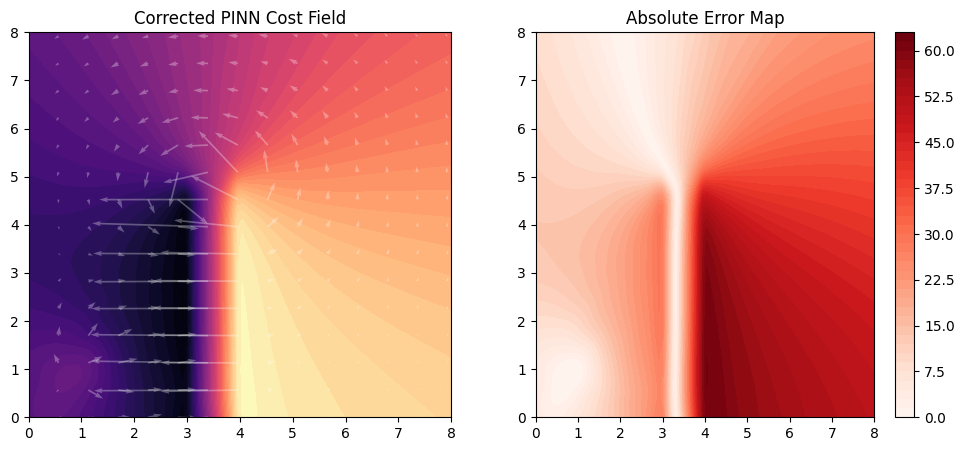

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

# 1. ARCHITECTURE
class ActivePerceptionPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

# 2. PHYSICS SETUP
def get_world_physics(samples):
    velocity = torch.ones((samples.shape[0], 1))
    wall_mask = (samples[:, 0] > 3.0) & (samples[:, 0] < 4.0) & (samples[:, 1] < 5.0)
    velocity[wall_mask] = 0.01
    friction_mask = (samples[:, 0] > 5.0) & (samples[:, 1] > 5.0)
    velocity[friction_mask] = 0.5
    return velocity

def eikonal_physics_loss(model, coords):
    coords.requires_grad = True
    u = model(coords)
    # FIXED LINE BELOW: Removed 'create_grad_predict'
    grads = torch.autograd.grad(u, coords, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    grad_norm = torch.norm(grads, dim=1, keepdim=True)
    v = get_world_physics(coords)
    return torch.mean((grad_norm - (1.0 / v))**2)

# 3. TRAINING
pinn = ActivePerceptionPINN()
pinn.apply(init_weights)
optimizer = optim.Adam(pinn.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1500, gamma=0.5)
goal = torch.tensor([[1.0, 1.0]], dtype=torch.float32)

print("Starting Corrected Training...")
for epoch in range(4001):
    optimizer.zero_grad()
    loss_boundary = torch.mean(pinn(goal)**2)
    colloc = torch.rand((1000, 2)) * 8.0
    loss_phys = eikonal_physics_loss(pinn, colloc)

    # Weight balancing: Boundary is king
    total_loss = 100.0 * loss_boundary + loss_phys

    total_loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Total Loss: {total_loss.item():.5f}")

# 4. FINAL DEFENSE & VISUALIZATION
def final_viva_defense(model, goal_pos):
    model.eval()
    res = 100
    grid_size = 8

    # Ground Truth
    mask = np.ones((res, res))
    gy, gx = int(goal_pos[1]*res/grid_size), int(goal_pos[0]*res/grid_size)
    mask[gy, gx] = 0
    gt_map = distance_transform_edt(mask) * (grid_size/res)

    # Predictions
    x = np.linspace(0, 8, res)
    y = np.linspace(0, 8, res)
    X, Y = np.meshgrid(x, y)
    pts = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)
    pts.requires_grad = True
    u_out = model(pts)

    # Gradients for Arrows
    grads = torch.autograd.grad(u_out, pts, torch.ones_like(u_out))[0]
    u_pred = u_out.detach().reshape(res, res).numpy()
    U_vec = -grads[:, 0].reshape(res, res).detach().numpy()
    V_vec = -grads[:, 1].reshape(res, res).detach().numpy()

    l2_error = np.linalg.norm(u_pred - gt_map) / np.linalg.norm(gt_map)
    print(f"\n[TEST SCORE] L2 Relative Error: {l2_error * 100:.2f}%")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.contourf(X, Y, u_pred, levels=50, cmap='magma')
    plt.quiver(X[::7, ::7], Y[::7, ::7], U_vec[::7, ::7], V_vec[::7, ::7], color='white', alpha=0.3)
    plt.title("Corrected PINN Cost Field")

    plt.subplot(1, 2, 2)
    error_map = np.abs(u_pred - gt_map)
    plt.contourf(X, Y, error_map, levels=50, cmap='Reds')
    plt.title("Absolute Error Map")
    plt.colorbar()
    plt.show()

final_viva_defense(pinn, [1.0, 1.0])